In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_movies = pd.read_csv('../datasets/movies.csv')
df_ratings = pd.read_csv('../datasets/ratings.csv')

In [3]:
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [5]:
df_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 10329 entries, 0 to 10328
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  10329 non-null  int64
 1   title    10329 non-null  str  
 2   genres   10329 non-null  str  
dtypes: int64(1), str(2)
memory usage: 242.2 KB


In [6]:
df_ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     105339 non-null  int64  
 1   movieId    105339 non-null  int64  
 2   rating     105339 non-null  float64
 3   timestamp  105339 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.2 MB


In [7]:
df_movies.describe()

,movieId
count,10329.000000
mean,31924.282893
std,37734.741149
min,1.000000
25%,3240.000000
50%,7088.000000
75%,59900.000000
max,149532.000000


In [8]:
df_ratings.describe()

,userId,movieId,rating,timestamp
count,105339.000000,105339.000000,105339.000000,1.053390e+05
mean,364.924539,13381.312477,3.516850,1.130424e+09
std,197.486905,26170.456869,1.044872,1.802660e+08
min,1.000000,1.000000,0.500000,8.285650e+08
25%,192.000000,1073.000000,3.000000,9.711008e+08
50%,383.000000,2497.000000,3.500000,1.115154e+09
75%,557.000000,5991.000000,4.000000,1.275496e+09
max,668.000000,149532.000000,5.000000,1.452405e+09


# 1. Count Ratings per Movie

In [9]:
rating_counts = df_ratings.groupby('movieId')['rating'].count().reset_index()
rating_counts

,movieId,rating
0,1,232
1,2,92
2,3,58
3,4,11
4,5,62
...,...,...
10320,146684,1
10321,146878,1
10322,148238,1
10323,148626,3


In [10]:
rating_counts['rating'].describe()

count    10325.000000
mean        10.202324
std         22.832341
min          1.000000
25%          1.000000
50%          3.000000
75%          8.000000
max        325.000000
Name: rating, dtype: float64

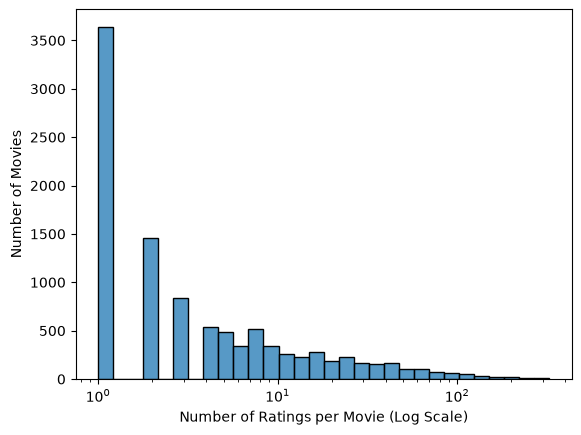

In [11]:
# Plot the histogram using a logarithmic scale
sns.histplot(data=rating_counts, x='rating', log_scale=True, bins=30, kde=False)
plt.xlabel('Number of Ratings per Movie (Log Scale)')
plt.ylabel('Number of Movies')
plt.show()

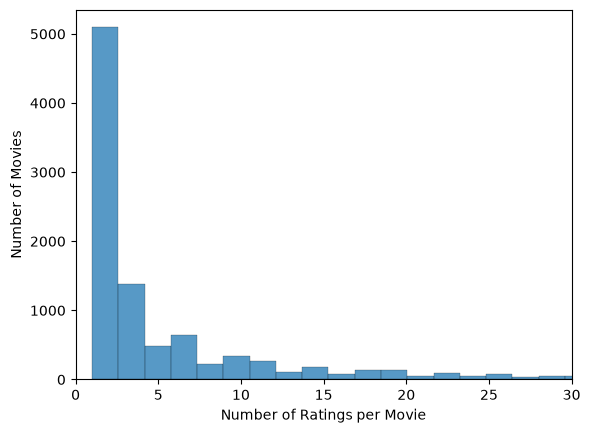

In [12]:
# Plot the histogram with the x-axis limited to 30 ratings.
sns.histplot(data=rating_counts, x='rating')
plt.xlim(0, 30)
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Number of Movies')
plt.show()

# 2. Count Ratings per User

In [13]:
ratings_per_user = df_ratings.groupby('userId')['rating'].count()
ratings_per_user

userId
1       113
2        29
3        73
4       124
5        68
       ... 
664      74
665     227
666     225
667      74
668    5678
Name: rating, Length: 668, dtype: int64

In [14]:
ratings_per_user.describe()

count     668.000000
mean      157.693114
std       319.712512
min        20.000000
25%        35.000000
50%        70.500000
75%       153.000000
max      5678.000000
Name: rating, dtype: float64

# 3. Filter Movies by Minimum Rating Count

In [15]:
# Identify movies with enough ratings to be included in the analysis
valid_movie_ids = rating_counts.query('rating >= 3')['movieId']
valid_movie_ids

0             1
1             2
2             3
3             4
4             5
          ...  
10261    135887
10263    136020
10272    138036
10283    139644
10323    148626
Name: movieId, Length: 5232, dtype: int64

In [16]:
# Keep only ratings for movies that meet the minimum rating count
filtered_ratings = df_ratings[df_ratings['movieId'].isin(valid_movie_ids)]
filtered_ratings

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523
...,...,...,...,...
105322,668,134368,4.0,1434287418
105323,668,134393,3.5,1449946649
105326,668,136020,4.0,1447644756
105330,668,139644,4.0,1452195888


In [17]:
total_ratings = df_ratings.shape[0]
remaining_ratings = filtered_ratings.shape[0]
removed_ratings = total_ratings - remaining_ratings

print(
    f'Ratings before filtering : {total_ratings}\n'
    f'Ratings removed          : {removed_ratings}\n'
    f'Ratings remaining        : {remaining_ratings}'
)

Ratings before filtering : 105339
Ratings removed          : 6548
Ratings remaining        : 98791


In [18]:
# Keep only movies that meet the minimum rating count
filtered_movies = df_movies[df_movies['movieId'].isin(valid_movie_ids)]
filtered_movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
10265,135887,Minions (2015),Adventure|Animation|Children|Comedy
10267,136020,Spectre (2015),Action|Adventure|Crime
10276,138036,"Man from U.N.C.L.E., The (2015)",Action|Adventure|Comedy
10287,139644,Sicario (2015),Crime|Drama|Mystery


In [19]:
total_movies = df_movies.shape[0]
remaining_movies = filtered_movies.shape[0]
removed_movies = total_movies - remaining_movies

print(
    f'Movies before filtering : {total_movies}\n'
    f'Movies removed          : {removed_movies} (< 3 ratings)\n'
    f'Movies remaining        : {remaining_movies}'
)

Movies before filtering : 10329
Movies removed          : 5097 (< 3 ratings)
Movies remaining        : 5232
